🔹 Cell 1: Imports

In [5]:
import joblib

X_train, X_test, y_train, y_test = joblib.load("processed_data.pkl")

In [6]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1)
}

In [9]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [10]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="R2 Score", ascending=False)

,Model,MSE,RMSE,R2 Score
2,XGBoost,29.677761,5.447730,0.879310
1,Random Forest,33.990242,5.830115,0.861773
0,Linear Regression,51.213491,7.156360,0.791731


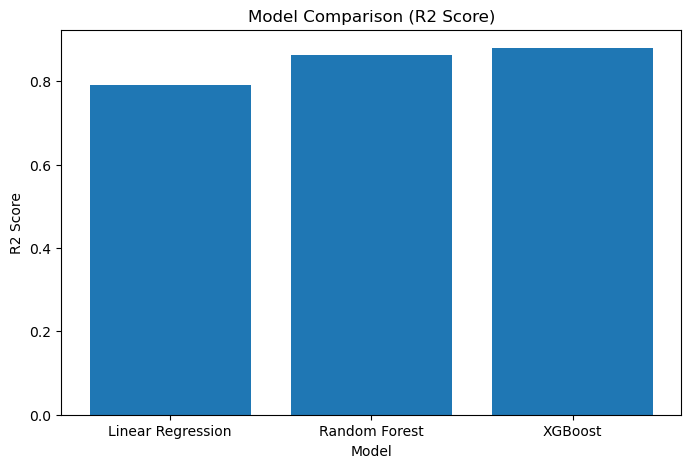

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.show()

In [12]:
best_model = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]

print("Best Model:", best_model["Model"])

Best Model: XGBoost


### Model Comparison

- Multiple models were trained and evaluated using MSE, RMSE, and R² score.  
- Linear Regression serves as a baseline model.  
- Random Forest captures non-linear relationships better.  
- XGBoost provides improved performance due to boosting techniques.  

**Insight:**  
The model with the highest R² score is selected as the best-performing model for demand prediction.

### Model Comparison Results

- Three models were evaluated: Linear Regression, Random Forest, and XGBoost.  
- Linear Regression performed the weakest, indicating that the relationship is not purely linear.  
- Random Forest improved performance by capturing non-linear patterns.  
- XGBoost achieved the highest R² score and lowest error values.

**Insight:**  
XGBoost is the best-performing model as it effectively captures complex relationships between features and demand.